# **Using Machine Learning to Analyze Voice Disorders for Parkinson's Disease Detection**


The purpose of this project is to develop a machine learning model that can accurately predict the presence of Parkinson's disease in an individual based on their voice recordings. Parkinson's disease is a neurodegenerative disorder that affects movement, with symptoms that include tremors, stiffness, and difficulty with coordination.

<div style="text-align:center">
<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-GPXX01JCEN/images/parkinson_patient_voice.png" width="500" alt="parkinson detection">
</div>


## __Table of Contents__

<ol>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-Required-Libraries">Installing Required Libraries</a></li>
        </ol>
    </li>
    <li>
        <a href="#Parkinson Data and Voice Disorder">Parkinson Data and Voice Disorder</a>
    </li>
    <li><a href="#Loading Data">Loading Data</a></li>
    <li><a href="#Data Preparation">Data Preparation</a></li>
    <li><a href="#Train and Test Random Forest">Train and Test Random Forest Model</a></li>
    <li><a href="#Visualizing the decision tree">Find Strong Model</a></li>
</ol>


## Objectives

After completing this lab you will be able to:

- Use Python for data analysis and machine learning
- Implement machine learning algorithms to detect Parkinson's disease in voice recordings
- Evaluate model performance
- Conduct grid search for tuning parameters
- Visualize the decision tree model


----


## Setup


### Installing Required Libraries


The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them. `%%capture` is to capture and hide the outputs of the following commands.


In [1]:
%%capture   
!mamba install --upgrade scikit-learn=1.2.1
!pip install seaborn

In [2]:
!pip install dtreeviz


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install skillsnetwork


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<center>
<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-GPXX01JCEN/Sam.png" alt="example image" title="Example Image" width="300" height="200">


> You need to **restart kernel** by clicking on `Kernel` menu and choosing `Restart kernel`.


In [4]:
import skillsnetwork
await skillsnetwork.download_dataset("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-GPXX01JCEN/data/parkinsons.data")

Saved as 'parkinsons.data'


### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [5]:
import skillsnetwork
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pickle
import dtreeviz
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score

# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn    # Override the default warning function by assingning a custome function
warnings.filterwarnings('ignore')

Creating helper function for plotting.

In [6]:
sns.set(style='whitegrid', color_codes=True)

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
        """
        This function prints and plots the confusion matrix.
        Normalization can be applied by setting `normalize=True`.
        """
        plt.imshow(cm, interpolation='nearest', cmap=cmap)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=45)
        plt.yticks(tick_marks, classes)    #???????????

        # Normalize the confusion matrix by row (based on the actual labels)
        if normalize:
                # np.newaxis is the same as None to add new axis to the array
                cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] 
                cm = cm.round(3)
                print("Normalized confusion matrix")
        else:
                print("Confusion matrix without normalization")
        print(cm) 

        thresh = cm.max() * 3 / 4    # Set a threshold for text color
        # Try all combinations of i and j for the confusion matrix dimensions
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):  
                plt.text(j, i, cm[i, j], 
                         horizontalalignment='center',
                         color='white' if cm[i, j] > thresh else 'black')
        
        plt.tight_layout()  # Adjust the padding between and around subplots
        plt.ylabel('True label')
        plt.xlabel('Predicted label')

## Parkinson Data and Voice Disorder

<a href=https://archive.ics.uci.edu/ml/datasets/parkinsons>Voice disorder dataset</a> can be used to detect the presence of Parkinson's disease in an individual. While current tools have limitations in analyzing complex voice disorders, advancements in technology and research have enabled the development of new algorithms that can identify specific acoustic markers associated with Parkinson's disease in voice recordings. Therefore, the analysis of voice disorders can provide valuable information in diagnosing and monitoring Parkinson's disease.



This dataset is composed of a range of biomedical voice measurements from 31 people, 23 with Parkinson's disease (PD).  Our dataset includes voice attributes Information that can be used for detecting parkinson, these information including:


Matrix column entries (attributes):  
- name - ASCII subject name and recording number
- MDVP:Fo(Hz) - Average vocal fundamental frequency
- MDVP:Fhi(Hz) - Maximum vocal fundamental frequency
- MDVP:Flo(Hz) - Minimum vocal fundamental frequency
- Five measures of variation in Frequency
    - MDVP:Jitter(%) - Percentage of cycle-to-cycle variability of the period duration
    - MDVP:Jitter(Abs) - Absolute value of cycle-to-cycle variability of the period duration
    - MDVP:RAP - Relative measure of the pitch disturbance
    - MDVP:PPQ - Pitch perturbation quotient
    - Jitter:DDP - Average absolute difference of differences between jitter cycles
- Six measures of variation in amplitude
    - MDVP:Shimmer - Variations in the voice amplitdue
    - MDVP:Shimmer(dB) - Variations in the voice amplitdue in dB
    - Shimmer:APQ3 - Three point amplitude perturbation quotient measured against the average of the three amplitude
    - Shimmer:APQ5 - Five point amplitude perturbation quotient measured against the average of the three amplitude
    - MDVP:APQ - Amplitude perturbation quotient from MDVP
    - Shimmer:DDA - Average absolute difference between the amplitudes of consecutive periods
- Two measures of ratio of noise to tonal components in the voice
    - NHR - Noise-to-harmonics Ratio and 
    - HNR - Harmonics-to-noise Ratio
- **Status (target)** - Health status of the subject (one) - Parkinson's, (zero) - healthy
- Two nonlinear dynamical complexity measures
    - RPDE - Recurrence period density entropy
    - D2 - correlation dimension
- DFA - Signal fractal scaling exponent
- Three nonlinear measures of fundamental frequency variation
    - spread1 - discrete probability distribution of occurrence of relative semitone variations
    - spread2 - Three nonlinear measures of fundamental frequency variation
    - PPE - Entropy of the discrete probability distribution of occurrence of relative semitone variations


## Loading data


In [7]:
data = pd.read_csv('parkinsons.data', sep=',', index_col='name')
data.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
name,,,,,,,,,,,,,,,,,,,,,
phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


We can see the number of samples:


In [8]:
data.shape

(195, 23)

To improve our understanding of the variables involved in parkinson detection, we first need to analyze the relationships within the data. Correlation diagrams can be helpful in visualizing how different variables are associated with each other and with parkinson status. Additionally, random forest models can help identify the importance of different features in predicting the target variable (parkinson).


<Axes: >

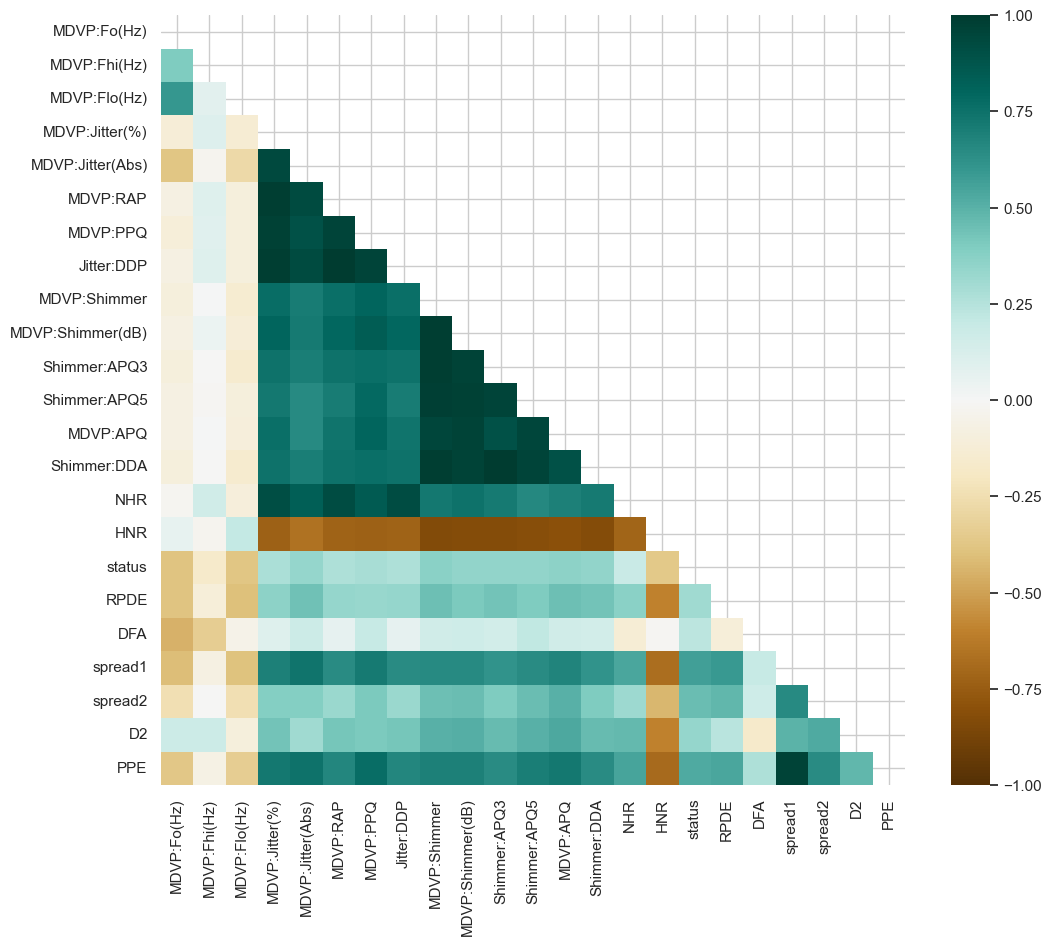

In [9]:
# creating the correlation matrix
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(data.corr(), dtype=np.bool))
sns.heatmap(data.corr(),vmin=-1, vmax=1,cmap='BrBG', mask=mask)

<Axes: >

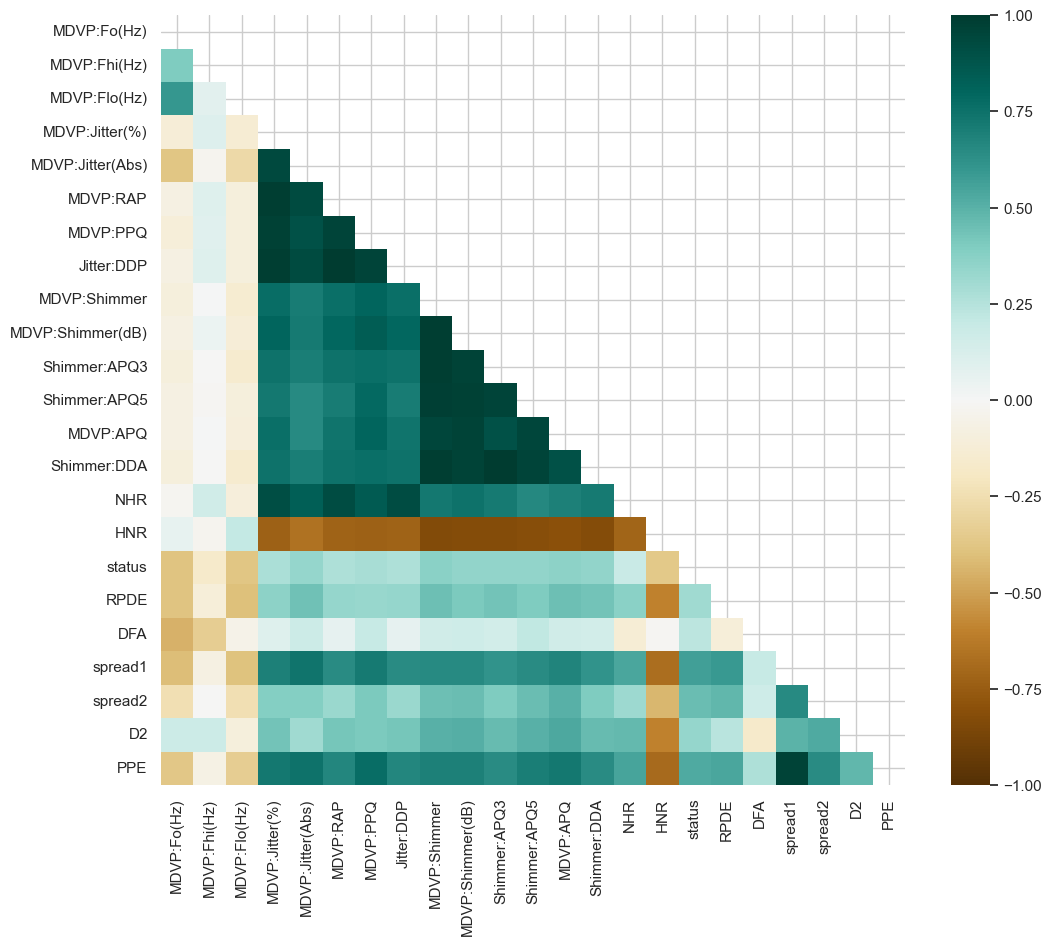

In [10]:
# Create the correlation matrix
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(data.corr(), dtype=np.bool))
# Cells where mask is True will not be shown
sns.heatmap(data.corr(), vmin=-1, vmax=1, cmap='BrBG', mask=mask)

Text(0.5, 1.0, 'Features Correlating with Parkinson Existence')

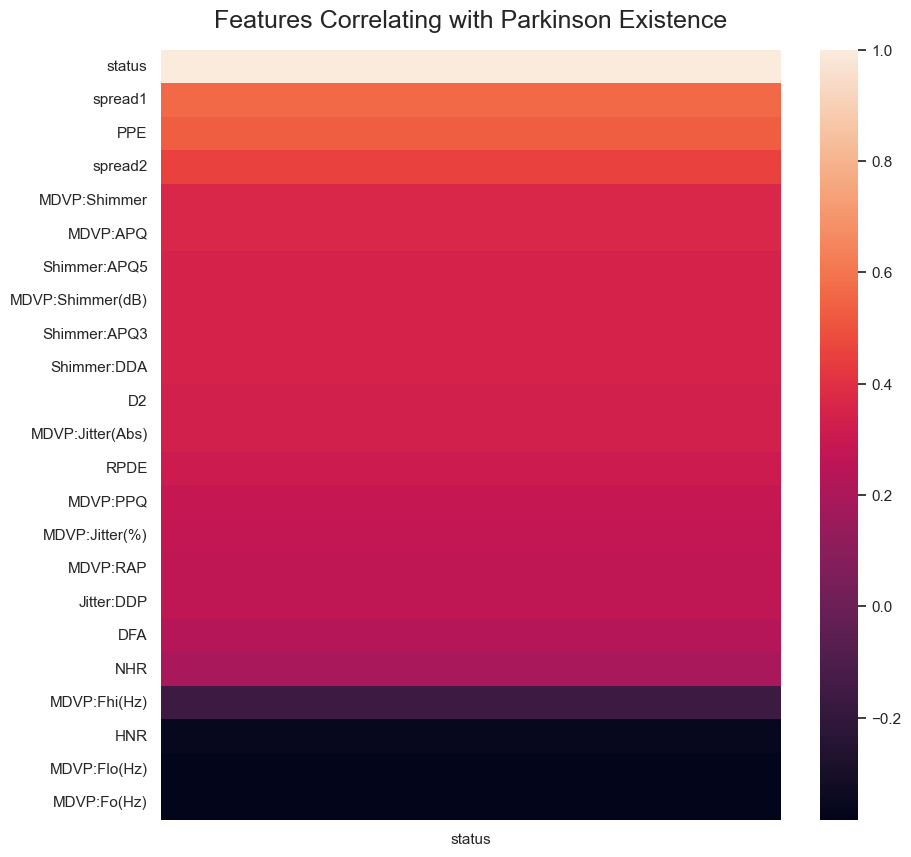

In [11]:
# Modify the heatmap plot to show correlation variables to the status variable
plt.figure(figsize=(10, 10))
heatmap = sns.heatmap(data.corr()[['status']].sort_values(by='status', ascending=False))
heatmap.set_title('Features Correlating with Parkinson Existence', fontdict={'fontsize':18}, pad=16)

In [12]:
X = data.drop('status', axis=1)
X.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
name,,,,,,,,,,,,,,,,,,,,,
phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


The   Health status of the subject (one) - Parkinson's, (zero) - healthy  is given in the ```status``` column:


In [13]:
y = data['status']
y.head()

name
phon_R01_S01_1    1
phon_R01_S01_2    1
phon_R01_S01_3    1
phon_R01_S01_4    1
phon_R01_S01_5    1
Name: status, dtype: int64

we can see that 3/4 of the samples are have Parkinson's:


In [14]:
print('Counts:\n', y.value_counts())
print('Rates:\n', y.value_counts(normalize=True))

Counts:
 status
1    147
0     48
Name: count, dtype: int64
Rates:
 status
1    0.753846
0    0.246154
Name: proportion, dtype: float64


t-SNE (t-Distributed Stochastic Neighbor Embedding) is a machine learning technique used for dimensionality reduction and **visualization** of high-dimensional datasets. It is particularly useful for visualizing complex data structures, as it helps to project the data points from a high-dimensional space to a lower-dimensional space (usually 2D or 3D) while preserving the relationships between the data points as much as possible. Lets apply it to our dataset:


  File "c:\Users\SK\Desktop\AI_Biomedical_Applications\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\SK\Desktop\AI_Biomedical_Applications\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\SK\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\SK\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\SK\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(exe

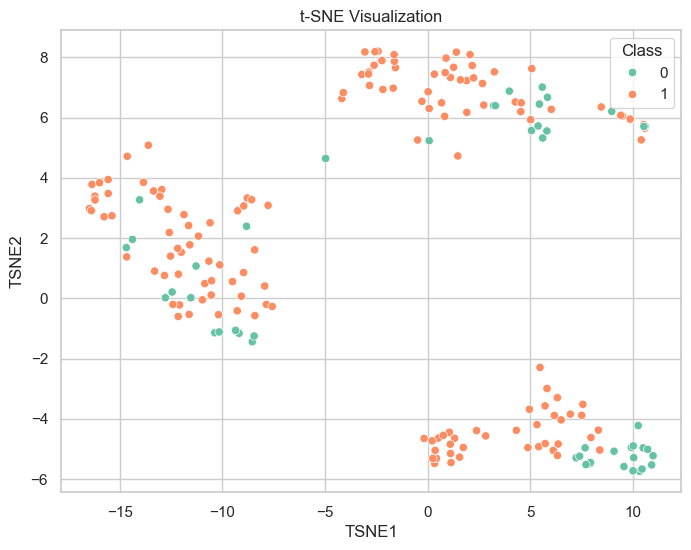

In [15]:
# Apply t-SNE to reduce the dimensions to 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Create a DataFrame with the t-SNE-transformed data and class lables
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Class'] = y.values

# Visualize the data based on class using a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Class', palette='Set2')
plt.title('t-SNE Visualization')
plt.show()

## Data preparation

Here, we have split a dataset into independent and dependent variables, and then will split it further into training and testing sets.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)
print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (136, 22)
y_train shape:  (136,)
X_test shape:  (59, 22)
y_test shape:  (59,)


## k-Nearest Neighbors (k-NN)


### K-NN 



In k-NN, the basic idea is to predict the label of a new instance based on the labels of its k nearest neighbors in the training data. 

We create and fit a KNN object:


In [17]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


 Make predictions on the testing data.


In [18]:
y_pred = knn.predict(X_test)
y_pred[0:10]

array([1, 0, 1, 1, 1, 1, 1, 0, 0, 0])

We can  get a probability of membership to a each class for each sample, here are the first ten.

In [19]:
knn.predict_proba(X_test)[0:10]

array([[0.33333333, 0.66666667],
       [0.66666667, 0.33333333],
       [0.33333333, 0.66666667],
       [0.33333333, 0.66666667],
       [0.        , 1.        ],
       [0.33333333, 0.66666667],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ]])

 The **confusion matrix** is a table that shows the number of true positive, true negative, false positive, and false negative predictions. The **classification report** provides the precision, recall, F1-score, and support for each class, which are important metrics for evaluating the performance of a classifier. The **accuracy score** is a simple metric that calculates the proportion of correct predictions out of the total predictions made by the model. These three elements together provide a comprehensive evaluation of the classifier's performance on the test dataset. Let's prints the confusion matrix, classification report, and accuracy score for a given classification model.


Confusion matrix without normalization
[[ 9  3]
 [ 5 42]]


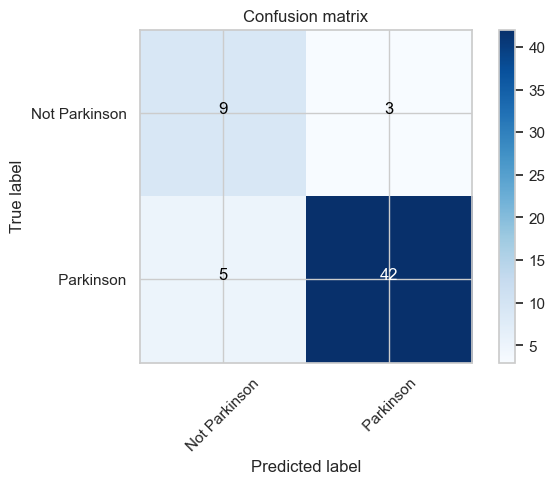

In [20]:
plot_confusion_matrix(confusion_matrix(y_test, y_pred),classes=[ "Not Parkinson", " Parkinson"],title='Confusion matrix')

In [21]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.75      0.69        12
           1       0.93      0.89      0.91        47

    accuracy                           0.86        59
   macro avg       0.79      0.82      0.80        59
weighted avg       0.87      0.86      0.87        59


Accuracy Score: 0.864406779661017


In [22]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 9,  3],
       [ 5, 42]])

Confusion matrix without normalization
[[ 9  3]
 [ 5 42]]


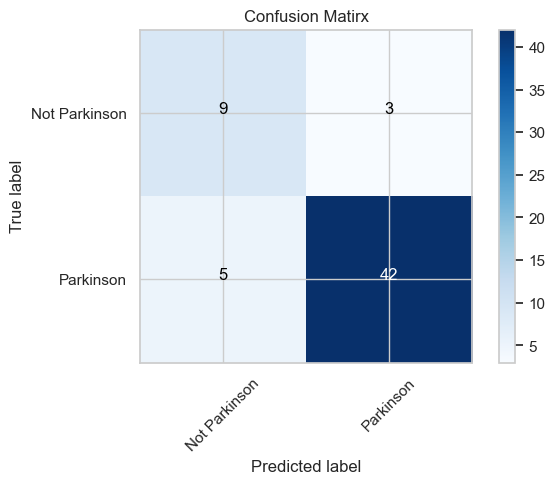

In [23]:
plot_confusion_matrix(cm, classes=['Not Parkinson', 'Parkinson'],
                      title='Confusion Matirx')

## GridSearchCV


In the code above, we randomly selected the hyperparameter ```K``` for our KNN classifier. However, in order to find the optimal hyperparameters that maximize the performance metric, we will perform a grid search. To do this, we define a parameter grid that we will search over for ```K```.


In [24]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9]
}

Define the KNN classifier object.

In [25]:
knn = KNeighborsClassifier()

In medical testing, recall is a measure of the ability of a test to correctly identify true positive cases, or the proportion of actual positive cases that are correctly identified by the test out of entire positive cases. A high recall means that the test is able to correctly identify a large proportion of true positive cases, even if it may also produce some false positive results, therefore for ```scoring``` we select recall. The choice of performance metric for a machine learning model may depend on several factors. 

The next cell  performs a grid search over the hyperparameters of a KNN classifier using ```GridSearchCV()``` function from scikit-learn library. The param_grid parameter specifies a dictionary of hyperparameters to search over, while the scoring parameter specifies the performance metric to optimize for, which in this case is the recall. The cv parameter specifies the number of folds for cross-validationv ```cv``` . The resulting grid_search object can be used to fit the data and obtain the best hyperparameters that maximize the performance metric.

In [26]:
# refit=True by default
grid_search = GridSearchCV(knn, param_grid, scoring='recall', cv=5)
grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramete

Fit the grid search to the training data.

In [27]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramete

Print the best parameters and score on validation data.

In [28]:
print("Best Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)

Best Parameters:  {'n_neighbors': 9}
Best Score:  0.97


Get the predicted labels on the test data using the best estimator:


In [29]:
y_pred = grid_search.best_estimator_.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Calculate the recall score on the test data using the predicted labels:


In [30]:
recall = recall_score(y_test, y_pred)
recall

0.9148936170212766

Fit the best estimator with entire data and predict on trained data.

In [31]:
grid_search.best_estimator_.fit(X, y)
y_hat = grid_search.best_estimator_.predict(X)
y_hat

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0])

We can plot the confusion matrix.

Confusion matrix without normalization
[[ 28  20]
 [  6 141]]


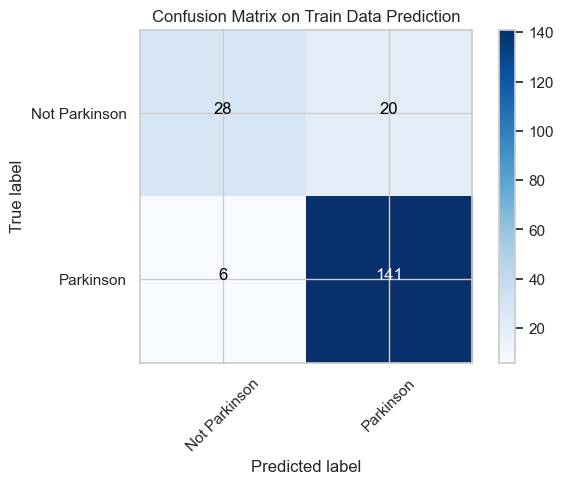

In [32]:
plot_confusion_matrix(confusion_matrix(y, y_hat),
                      classes=['Not Parkinson', 'Parkinson'],
                      title='Confusion Matrix on Train Data Prediction')

### Machine Learning Interpretability
Machine learning interpretability refers to the ability to understand and explain how a machine learning model arrives at its predictions or decisions. It is an important aspect of machine learning because it enables users to gain insight into how a model works, assess its strengths and limitations, and identify potential issues such as bias, errors, or overfitting. Interpretability can be achieved through a variety of techniques such as visualizations, feature importance scores, model-agnostic methods, and explanations of specific decisions. 
T-SNE can be used for machine learning interpretability by visualizing high-dimensional data in a two-dimensional space.  For example, in the context of clustering, t-SNE can be used to visualize the clusters in a two-dimensional space, making it easier to identify patterns and relationships between the data points. This can help to identify outliers, clusters that are not well-separated, and potentially interesting subsets of the data that may warrant further investigation. Let's label our predictions.


In [33]:
label = np.empty(len(y), dtype='object')
label[np.where((y==1) & (y_hat==1))] = 'TP'
label[np.where((y==0) & (y_hat==0))] = 'TN'
label[np.where((y==1) & (y_hat==0))] = 'FN'
label[np.where((y==0) & (y_hat==1))] = 'FP'
tsne_df['Label'] = label
tsne_df

,TSNE1,TSNE2,Class,Label
0,-4.180665,6.632692,1,TP
1,-7.937240,0.406959,1,TP
2,-10.542571,0.108473,1,TP
3,-9.506589,0.555806,1,TP
4,-8.966320,0.855434,1,TP
...,...,...,...,...
190,3.212926,6.401083,0,FP
191,5.442439,6.449479,0,TN
192,3.296127,6.396221,0,FP
193,8.966993,6.208067,0,FP


Let's plot the data, with the labeled predictions.

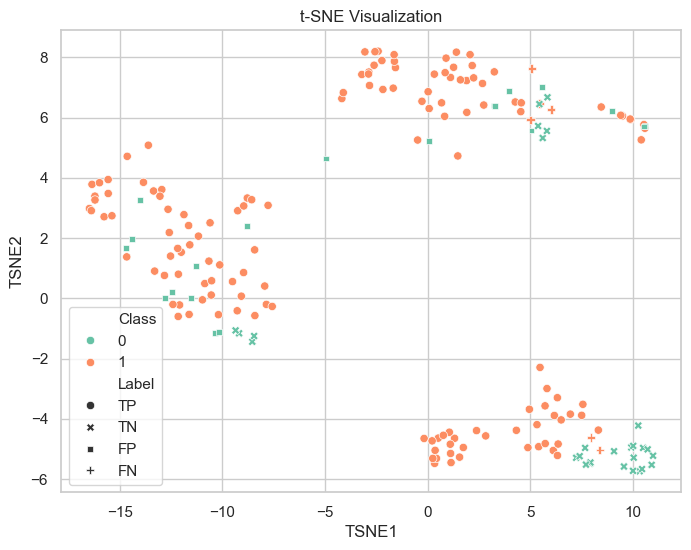

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Class', palette='Set2', style='Label')
plt.title('t-SNE Visualization')
plt.show()

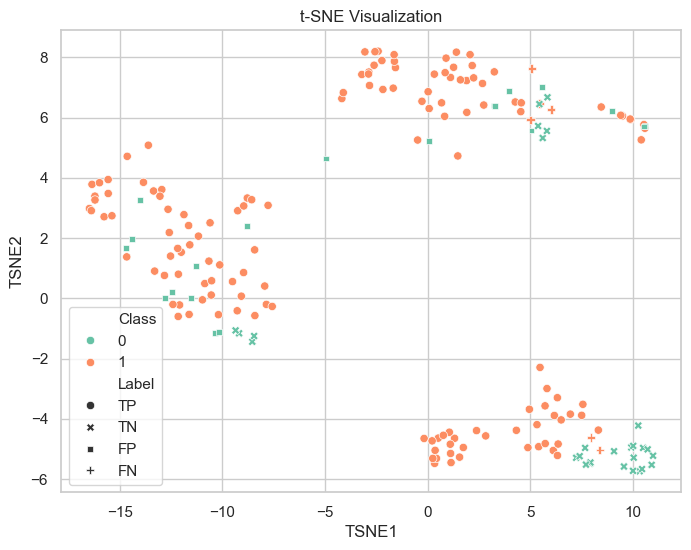

In [35]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Class', palette='Set2', style='Label')
plt.title('t-SNE Visualization')
plt.show()

From the plot, we see most of the errors are confined to specific clusters. We can apply clustering to our data before we classify the data, but let's try several other models. Here are several more libraries for Machine Learning Interpretability.


<ul>
  <li><a href="https://github.com/slundberg/shap">SHAP</a></li>
  <li><a href="https://github.com/marcotcr/lime">LIME</a></li>
  <li><a href="https://github.com/oracle/Skater">Skater</a></li>
  <li><a href="https://github.com/microsoft/interpret">Microsoft InterpretML</a></li>
  <li><a href="https://github.com/interpretml/interpret-text">Interpret-text</a></li>
  <li><a href="https://github.com/interpretml/interpret-core">Interpret-core</a></li>
  <li><a href="https://github.com/surrey-unplugged/saliency">Saliency</a></li>
  <li><a href="https://github.com/PAIR-code/facets">Facets</a></li>
  <li><a href="https://github.com/marcotcr/photonai">Photonai</a></li>
</ul>


## Logistic Regression


Here's an example code for fitting a logistic regression model using scikit-learn.

We create and fit logistic regression model and fit it. We will not do hyperparameter optimization here.

In [36]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

We can check a prediction on the first ten samples.

In [37]:
y_pred = lr.predict(X_test)
y_pred[0:10]

array([1, 0, 1, 1, 1, 1, 1, 0, 0, 0])

We can get a probability of membership to a each class for each sample, here are the first ten.

In [38]:
lr.predict_proba(X_test)[0:10]

array([[0.26803548, 0.73196452],
       [0.69153977, 0.30846023],
       [0.06767167, 0.93232833],
       [0.38581147, 0.61418853],
       [0.07227122, 0.92772878],
       [0.26274932, 0.73725068],
       [0.00914075, 0.99085925],
       [0.51058449, 0.48941551],
       [0.85885749, 0.14114251],
       [0.90260201, 0.09739799]])

We can display the confusion matrix as well as a classification report.

Confusion matrix without normalization
[[ 9  3]
 [ 6 41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.75      0.67        12
           1       0.93      0.87      0.90        47

    accuracy                           0.85        59
   macro avg       0.77      0.81      0.78        59
weighted avg       0.86      0.85      0.85        59


Accuracy Score: 0.847457627118644


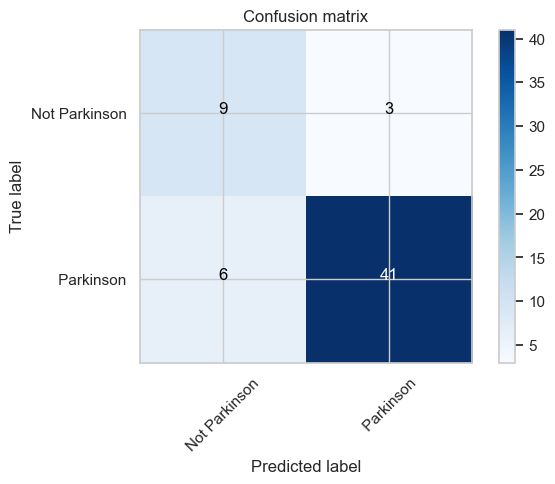

In [39]:
plot_confusion_matrix(confusion_matrix(y_test, y_pred),classes=[ "Not Parkinson", " Parkinson"],title='Confusion matrix')
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion matrix without normalization
[[ 9  3]
 [ 6 41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.75      0.67        12
           1       0.93      0.87      0.90        47

    accuracy                           0.85        59
   macro avg       0.77      0.81      0.78        59
weighted avg       0.86      0.85      0.85        59


Accuracy Score: 0.847457627118644


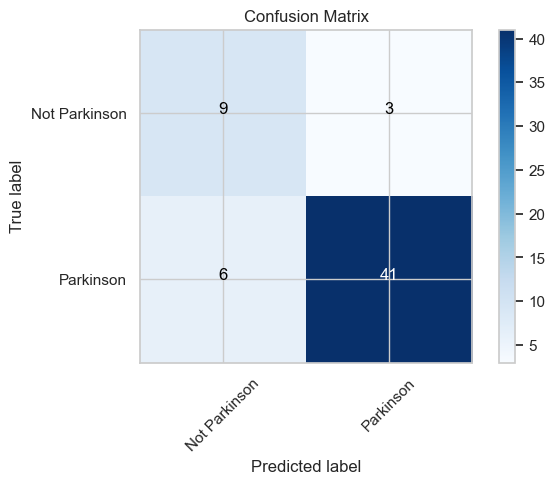

In [40]:
plot_confusion_matrix(confusion_matrix(y_test, y_pred), 
                      classes=['Not Parkinson', 'Parkinson'],
                      title='Confusion Matrix')
print('\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nAccuracy Score:', accuracy_score(y_test, y_pred))

While grid search can be used to optimize hyperparameters for many machine learning algorithms, the **hyperparameters in logistic regression may not be particularly insightful**. Instead, we can use logistic regression to identify feature importance, as the coefficients learned during training can reveal which features are most strongly associated with the target variable. We can obtain the coefficients.

In [41]:
coef = abs(lr.coef_)[0]
coef

array([2.37810183e-03, 4.41806982e-03, 3.29398522e-03, 8.81231990e-03,
       8.24787913e-05, 8.65197052e-03, 6.42728946e-03, 2.59345109e-02,
       1.61887141e-01, 1.54211405e+00, 8.67679190e-02, 9.63791648e-02,
       1.27965583e-01, 2.60288378e-01, 8.75803622e-03, 1.10383826e-01,
       6.83242087e-01, 9.06366584e-01, 1.24953555e+00, 8.02014612e-01,
       1.79718806e+00, 6.90523555e-01])

The coefficients represent the impact of each feature on the probability of the positive class, so larger the magnitude of the coefficients are more important the feature.


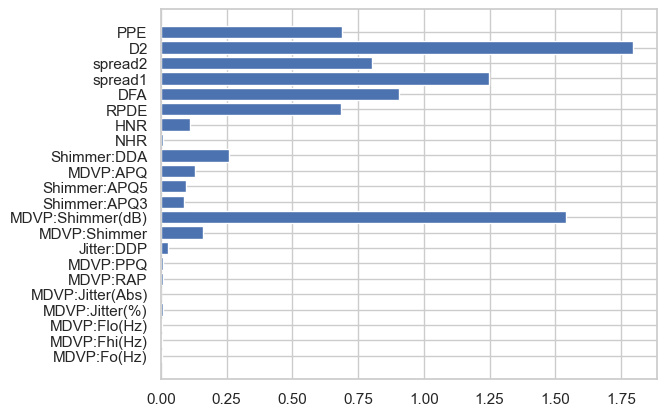

In [42]:
plt.barh(X.columns, coef)
plt.show()

We can select 5 features with the highest magnitude coefficients.

In [43]:
best_columns = X.columns[np.argsort(-1 * coef)[0:5]]
best_columns

Index(['D2', 'MDVP:Shimmer(dB)', 'spread1', 'DFA', 'spread2'], dtype='str')

Confusion matrix without normalization
[[10  2]
 [ 6 41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.83      0.71        12
           1       0.95      0.87      0.91        47

    accuracy                           0.86        59
   macro avg       0.79      0.85      0.81        59
weighted avg       0.89      0.86      0.87        59


Accuracy Score: 0.864406779661017


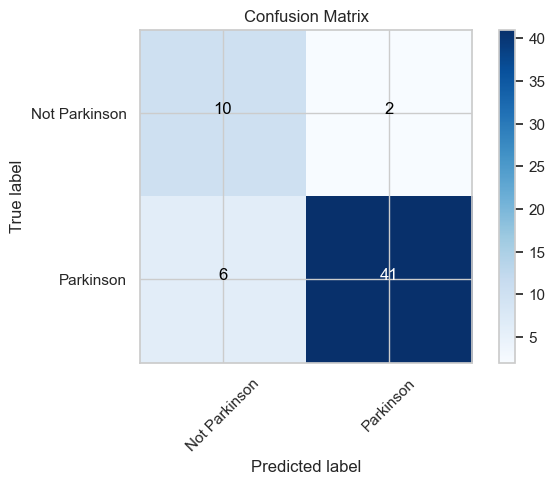

In [44]:
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train[best_columns], y_train)
y_pred = log_reg.predict(X_test[best_columns])

plot_confusion_matrix(confusion_matrix(y_test, y_pred),
                      classes=['Not Parkinson', 'Parkinson'],
                      title='Confusion Matrix')
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

We see many of the features are redundant, identifying and removing redundant features can potentially help in a few ways.

First, it can reduce the amount of data required for the model, which can reduce the cost of storing and processing data.

Second, it can improve the performance of the model, allowing it to make more accurate predictions with fewer resources. This can help reduce the cost of misclassifications or errors in the predictions.

Finally, it can also reduce the cost of model development and maintenance. Removing redundant features can simplify the model, making it easier to develop and maintain over time. It can also reduce the need for frequent updates and retraining, which can be costly in terms of time and resources.

## Support Vector Machines (SVM)


SVM stands for Support Vector Machines. It is a type of supervised machine learning algorithm used for classification. The algorithm identifies a hyperplane (or a set of hyperplanes) in an n-dimensional space that maximally separates the different classes in the dataset. The hyperplane that is selected is the one that has the maximum margin between the closest points of different classes, known as support vectors. SVM is particularly effective in high-dimensional datasets where other algorithms may have difficulty in identifying a clear boundary between the classes. SVM is also versatile in the type of kernel functions that can be used to transform the data into higher dimensions, such as linear, polynomial, and radial basis function (RBF) kernels.

Like Logistic Regression, SVM is a linear classifier but there are some Pros and Cons.

### Pros of SVM over Logistic Regression
<ul>
<li>Effective in high dimensional spaces and with datasets that have a lot of features</li>
<li>Can handle non-linearly separable data using kernel trick</li>
<li>Robust to overfitting due to the regularization parameter</li>
</ul>

### Cons of SVM compared to Logistic Regression
<ul>
<li>Can be computationally expensive to train, especially with large datasets</li>
<li>Difficult to interpret the results and understand the impact of each feature on the model</li>
<li>Requires careful selection of hyperparameters to achieve optimal performance</li>
</ul>

You can train a SVM just like any other model. 


### Exercise: Train and Test SVM Model using the SVC constructor and display the confusion matrix, use the appropriate datasets for each task.


Confusion matrix without normalization
[[ 4  8]
 [ 2 45]]


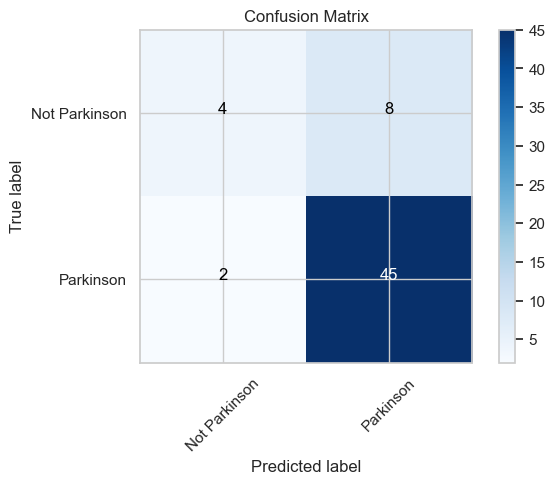

In [45]:
svm = SVC()
svm.fit(X_train, y_train)
y_hat = svm.predict(X_test)

plot_confusion_matrix(confusion_matrix(y_test, y_hat), 
                      classes=['Not Parkinson', 'Parkinson'],
                      title='Confusion Matrix')

Here are the explanations for some of the important parameters: 
    
```C:``` Regularization parameter. A smaller value of C creates a wider margin but may lead to more misclassifications, while a larger value of C creates a narrower margin but may lead to overfitting

```kernel:``` Type of kernel function used to transform the data into a higher-dimensional space where it can be linearly separated. Common choices include linear, polynomial, and radial basis function (RBF) kernels

```gamma:``` Kernel coefficient for RBF, polynomial, and sigmoid kernels. A smaller value of gamma creates a larger influence on radius for the support vectors (smooth and generalized boundary), while a larger value of gamma creates a smaller influence on radius and can lead to overfitting (complex and wiggly boundary)

```degree:``` Degree of the polynomial kernel function. Only used for polynomial kernel.    
    


Here is a dictionary for grid search with some of the specified parameters:


In [46]:
param_grid = {
    'C': [0.1, 1],
    'gamma': [0.1, 1, 10]
}

### Exercise:  Performing grid search on an SVM classifier with the specified hyperparameters and using recall as the scoring metric find the best hyperparameters and the corresponding recall score:


In [47]:
# Find the best hyperparameters
svm = SVC()
grid_search = GridSearchCV(svm, param_grid, scoring='recall', cv=5)
grid_search.fit(X_train, y_train)
print('Best parameters:', grid_search.best_params_)
print('Best recall score:', grid_search.best_score_)

Best parameters: {'C': 0.1, 'gamma': 0.1}
Best recall score: 1.0


In [48]:
# Predict with the best hyperparameters
y_pred = grid_search.best_estimator_.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [49]:
recall_score(y_test, y_pred)

1.0

Based on the result of recall 1.0 and y_pred being all 1, the model learned to predict every label to 1 to increase recall score. In this case, `precision` could be negatively impacted. So to increase both recall and precision with balance, get `f1` score for grid search again.

In [50]:
svm = SVC()
grid_search = GridSearchCV(svm, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)
print('Best parameters:', grid_search.best_params_)
print('Best f1 score:', grid_search.best_score_)

Best parameters: {'C': 1, 'gamma': 0.1}
Best f1 score: 0.851218008017268


In [51]:
y_pred = grid_search.best_estimator_.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [52]:
f1_score(y_test, y_pred)

0.8952380952380953

##  Random Forest Model


Random Forest is a good choice for various machine learning tasks due to its high accuracy in classifying complex data patterns. The ability to interpret the results of Random Forest models also makes it easier to validate and understand the decisions it makes.


In [53]:
rf = RandomForestClassifier(random_state=123)
rf. fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Accuracy score for performance evaluation
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy score: {acc:.2f}')

Accuracy score: 0.90


Exercise: Perform grid search for RandomForest to tune the parameters.


In [54]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=123)
# Scoring is default score for random forest model: accuracy
grid_search = GridSearchCV(rf, param_grid, cv=5)  
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best accuracy: {grid_search.best_score_:.2f}')

Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
Best accuracy: 0.87


With decision tree-based models, we can check the feature importance based on the impurity after fitting the model.

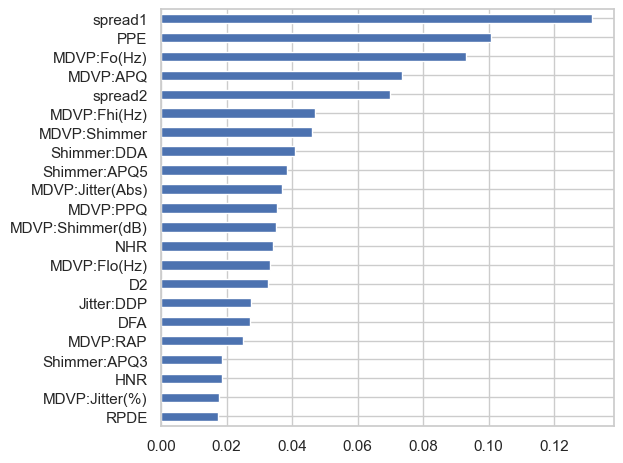

In [55]:
clf = grid_search.best_estimator_
imp = clf.feature_importances_
importance = pd.Series(imp, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.tight_layout()
plt.show()

Check the performance of the model on test data.

In [56]:
y_pred = clf.predict(X_test)
print('Accuracy on test data:', accuracy_score(y_test, y_pred))

Accuracy on test data: 0.9152542372881356


If the test data performance is acceptable, now we can refit the model with the entire data so that the model is used for deployment.

In [57]:
clf = clf.fit(X, y)

To save the trained model, we utilize liberary `pickle`.

In [58]:
file_name = 'rf_model_parkinson'
pickle.dump(clf, open(file_name, 'wb'))

In [59]:
# To use the model later
m = pickle.load(open('rf_model_parkinson', 'rb'))
m.get_params()   # Same parameters with the best estimator

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 50,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 123,
 'verbose': 0,
 'warm_start': False}

### Visualizing the Decision Trees

Using the `dtreeviz` library, we are able to visualize the decision tree. This can contribute to better the understanding of the role of our variables in identifying Parkinson.

At first, let's tune the parameters for the decision tree classifier:

In [60]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 4],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]
}

dt = DecisionTreeClassifier()
grid_search = GridSearchCV(dt, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('best f1:', grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
best f1: 0.9054295996401258


Apply the parameters to model and predict:


In [61]:
clf = grid_search.best_estimator_
y_pred = clf.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1])

In [62]:
round(f1_score(y_test, y_pred), 3)

0.909

Next, we plot the tree:


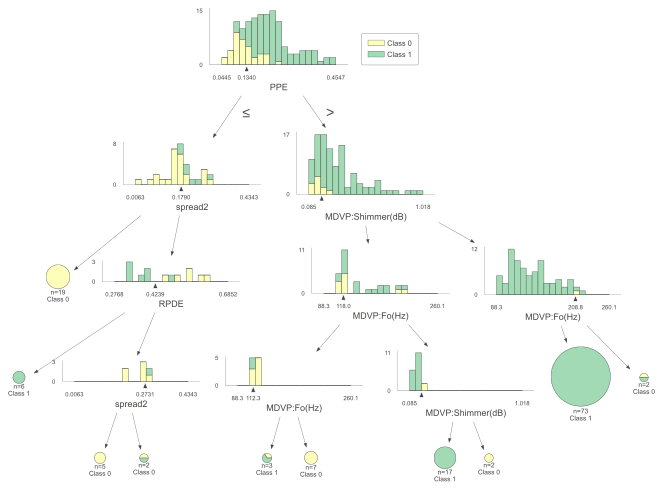

In [63]:
feature_names = list(grid_search.feature_names_in_)

# Visualize the tree
viz_model = dtreeviz.model(clf, X_train=X_train, y_train=y_train, feature_names=feature_names)
viz_model.view(fancy=True)

Let's choose a random point out of test data and visualize the decision path:


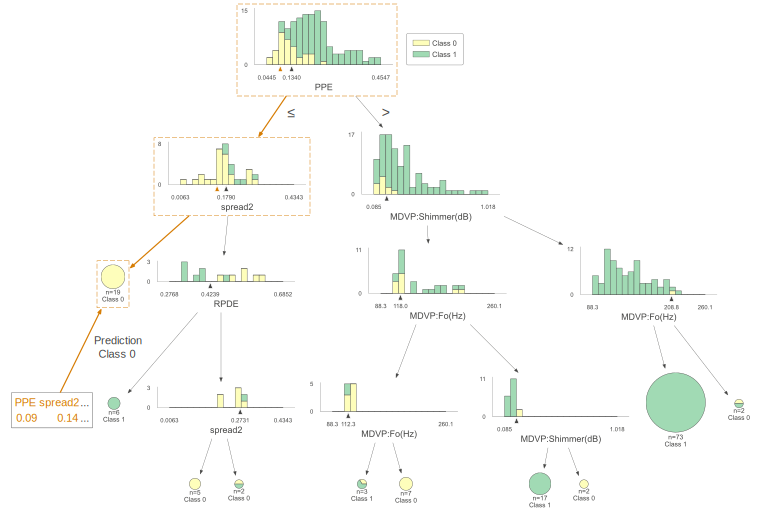

In [64]:
# Get a random point
rand = np.random.randint(0, len(X_test))
sample_point = X_test.iloc[rand, :].values

# Visualize the path for the point
viz_model.view(fancy=True, x=sample_point)

In [65]:
# Compare the predicted label with the actual label for the point
y_test.iloc[rand]

np.int64(1)

When a test data point is predicted on the tree model, the predicted label (class 1) is the same as the actual label. How the point is classified is clearly shown in the image.